# Glacier Hydraulic Tremor

This notebook starts the identification of glacier hydraulic tremor at Eqalorutsit Kangilliit Sermiat (Qajuuttap Sermia). We have 3 seismometers installed: QJT01, QJT02, QJT03 with the components 'HHZ','HHN','HHE' for the vertical, north, and east component of each seismometer. The sampling frequency is 200Hz.

In [2]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
import datetime
import obspy
import seaborn as sns
import math
import datetime
from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client
from multiprocessing import Pool
import statsmodels as sm

Matplotlib is building the font cache; this may take a moment.


## Week 11

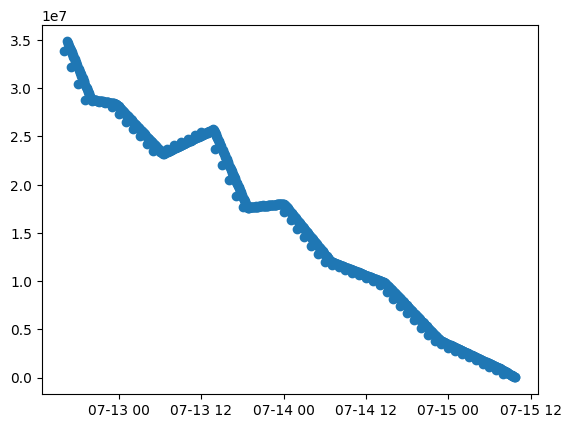

In [8]:
x = [12.760341981453193, 12.603423732623185, 13.059914014875295, 13.47360894536803, 13.673323851987835, 14.11554901698682, 14.457917055183508, 14.771754205858736, 15.128388014323757, 15.499286287026697, 16.155491475898614, 16.46932927958905, 16.797431547517405, 15.870185212744845, 12.902995766045287, 13.887303875860765]
y = [149.79452210489154, 150.89041152799484, 148.08219115804337, 146.16438388377065, 145.13698656980887, 143.56164297661155, 142.73972512544213, 142.1232867370651, 141.8493151651312, 141.78082305598966, 142.32876619985743, 142.80822036995144, 143.63013822112086, 141.98630251878203, 148.97260425372212, 144.383560827781]
pairs = sorted(list(zip(x,y)), key = lambda pair: pair[0])
x = [pair[0] for pair in pairs]
y = [- 5000000 * pair[1] for pair in pairs]
ten_sec = 300 / 60 / 60 / 24




xs = [0.5 * (x[i + 1] + x[i]) for i in range(len(x) - 1)]
ys = [(y[i + 1] - y[i]) / (x[i + 1] - x[i]) for i in range(len(x) - 1)]

xs_finals = []
# 12th, 16:21:55
start = 12 + 16/24 + 25/(24*60) 
curr = start
while curr < max(x):
    xs_finals.append(curr)
    curr += ten_sec

ys_finals = np.interp(xs_finals, xs, ys)
pairs = np.array(list(zip(xs_finals, ys_finals)))
pairs = pairs[pairs[:,1] > 0]
xs_finals  = pairs[:,0]

xs_finals = [datetime.datetime(year = 2024, 
                        month = 7, 
                        day = int(x // 1), 
                        hour = int((x % 1 * 24) // 1),
                        minute = round(((x % 1 * 24) % 1 * 60)) % 60,
                        second = 0) for x in xs_finals]

ys_finals = pairs[:,1]

fig, ax = plt.subplots()
ax.scatter(xs_finals, ys_finals)

discharge = dict(zip(xs_finals, ys_finals))


In [10]:
# Extract glacier hydraulic tremor signal from seismometer data with strong calving events.
GHT_dict = {}


client = Client('QJT_data')
t_start = xs_finals[0] - datetime.timedelta(minutes = 5)
t_end = datetime.datetime(2024, 7, 14)
# Times when valid seismometer data starts
start_dict = {'QJT01': datetime.datetime(2023,8,11,19),
            'QJT02': datetime.datetime(2023,8,14,19),
            'QJT03': datetime.datetime(2023,8,2,16)}

# Only looking at the vertical component
component = 'Z'

# Frequency range in which subglacial tremor is suspected (may be 3-30Hz)
freqbounds = [(1, 4), (4, 7), (7, 10)]
GHT_all = np.zeros((3, 144))

for freqmin, freqmax in freqbounds:
    # print("\n", freqmin, freqmax)
    sta = 'QJT03'
    t_list = []  # timestamps
    min_list = []  # integrated power in frequency band used for minimum search
    Pxx_min_list = []  # entire PSD at minimum

    # Set start time to the very beginning
    t_start_loop = t_start
    while t_start_loop<t_end:
        print(t_start_loop, end='\r')
        
        # Read data
        st = client.get_waveforms('XH', sta, '', '*'+component,
                                    UTCDateTime(t_start_loop), 
                                    UTCDateTime(t_start_loop+datetime.timedelta(days=1)))
        st.merge(fill_value=0)  # fills data gaps and makes handling easier
        if len(st)>0 and st[0].stats.npts>1:  # only do the analysis if data is present
            
            # Remove data when people were present at station
            if st[0].stats.starttime.date == start_dict[sta].date():
                st.trim(UTCDateTime(start_dict[sta]), st[0].stats.endtime)
            
            # Calculate spectrogram
            Fs = st[0].stats.sampling_rate
            NFFT = 5*Fs  # 5s bins for FFT
            Pxx, freqs, bins, _ = plt.specgram(st[0].data, NFFT=int(NFFT), Fs=Fs, noverlap=0)
            plt.close()
    
            # Select relevant data for minimum power detection
            idx_low = (np.abs(freqs - freqmin)).argmin()
            idx_high = (np.abs(freqs - freqmax)).argmin()
            Pxx_cut = Pxx[idx_low:idx_high]
            freqs_cut = freqs[idx_low:idx_high]
        
            # Integrate over selected frequency band
            Pxx_int = np.sum(Pxx_cut, axis=0)
        
            # Define chunk size in bins
            chunk_size = int(10*60 / (NFFT/Fs))  # 10min
            
            # Calculate how much padding is needed (if len(bins)%chunk_size!=0)
            padding_length = chunk_size - (len(Pxx_int) % chunk_size)
            if padding_length != chunk_size:  # Only pad if necessary
                Pxx_int = np.pad(Pxx_int, (0, padding_length), constant_values=np.nan)
                bins = np.pad(bins, (0, padding_length), constant_values=np.nan)
                Pxx = np.pad(Pxx, pad_width=((0, 0), (0, padding_length)), constant_values=np.nan)
    
            # Reshape into chunks
            reshaped_data = Pxx_int.reshape(-1, chunk_size)
            reshaped_bins = bins.reshape(-1, chunk_size)
            Pxx = Pxx.reshape(Pxx.shape[0], int(Pxx.shape[1]/chunk_size), -1).transpose(1,0,2)
            
            # Calculate the minimum of each chunk
            min_values = np.nanmin(reshaped_data, axis=1)
            min_idx = np.argmin(reshaped_data, axis=1)
            
            # Get PSD with minimum power
            Pxx_select = Pxx[np.arange(Pxx.shape[0]),:,min_idx].T
            
            # Fake timestamp of chunk (center of bin)
            t_stamps = [(st[0].stats.starttime+t).datetime for t in np.nanmean(reshaped_bins, axis=1)]

            # Append to lists
            min_list.append(min_values)
            t_list.append(t_stamps)
            Pxx_min_list.append(Pxx_select)

        # Continue in while loop
        t_start_loop+=datetime.timedelta(days=1)

    # Convert list of arrays to array
    t_all = np.concatenate(t_list)
    min_all = np.concatenate(min_list)
    Pxx_all = np.concatenate(Pxx_min_list, axis=1)

    # Save results for each station into dictionary
    GHT_dict[(freqmin, freqmax)] = {'t': t_all,
                                    'GHT': min_all}
    # GHT_all[(freqmin - 1) // 3,:] = min_all
    # GHT_dict[(freqmin, freqmax)] = {'t': t_all,
    #                                 'GHT': min_all,
    #                                 'PSD': Pxx_all} #saves entire PSD

# np.savez_compressed("results\\"+ str((t_start - datetime.datetime(2023,9,1)).days), times = t_all, GHT = GHT_all)



In [11]:
df_list = []

# Put GHT data into DataFrames
for sta in GHT_dict.keys():
    t = GHT_dict[sta]['t'].copy()
    GHT = GHT_dict[sta]['GHT'].copy()
    df = pd.DataFrame(data=GHT, index=t, columns=[sta])
    df = df.iloc[:-2] # remove some data when humans were reading out data at the station
    df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[freqbounds].std(axis='columns')

# df_ght.index.to_pydatetime() > xs_finals[0]

Text(0.5, 1.0, 'Discharge vs. tremor power')

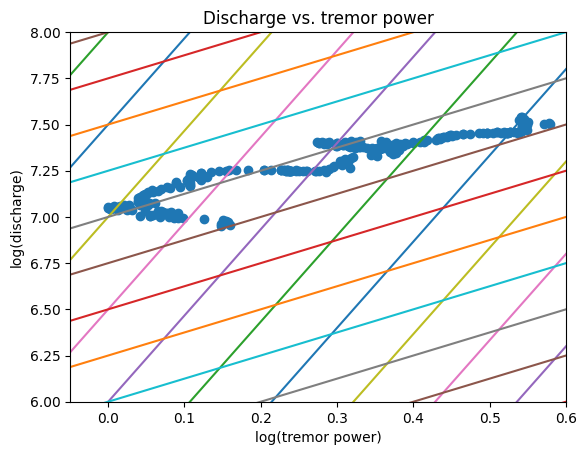

In [16]:
# fig = plt.figure(figsize=(2*6.4,4.8))
# for freqbound in freqbounds:
#     plt.plot(df_ght.index, np.sqrt(df_ght[freqbound]))
#     plt.fill_between(df_ght.index, df_ght[freqbound], df_ght[freqbound])
# plt.fill_between(df_ght.index, np.sqrt(df_ght['mean']-df_ght['std']), np.sqrt(df_ght['mean']+df_ght['std']))
# plt.ylabel('Relative Subglacial Discharge')
# plt.xlabel('Time')

df_ght["discharge"] = df_ght.index.to_series().apply(lambda x: discharge[pd.to_datetime(x).to_pydatetime()])

fig, ax = plt.subplots()
for i in range(-100, 100, 1):
    ax.plot(np.linspace(-0.1, 0.6, 50), (i / 2) + 14 / 3 * np.linspace(-0.1, 0.6, 50))
    ax.plot(np.linspace(-0.1, 0.6, 50), (i / 4) + 5 / 4 * np.linspace(-0.1, 0.6, 50))
ax.scatter(np.log10(df_ght["mean"].to_numpy()), np.log10(df_ght["discharge"].to_numpy()))
ax.set_ylim(6, 8)
ax.set_xlim(-0.05, 0.6)
ax.set_xlabel("log(tremor power)")
ax.set_ylabel("log(discharge)")
ax.set_title("Discharge vs. tremor power")



## Week 9 and 10

In [3]:
# Example for July 2024
t_start = datetime.datetime(2023,9,1)
t_end = datetime.datetime(2024,7,11)
days = (t_end - t_start).days

# with Pool() as p:
    # p.map(est_signal, [datetime.datetime(2024,7,1), datetime.datetime(2024,7,2)])
# Path to the data !!! needs to be adjusted !!!

# [t_start + datetime.timedelta(days = i) for i in range(days)]
# for i in range(days):
#     est_signal(t_start + datetime.timedelta(days = i))

In [ ]:
# Extract glacier hydraulic tremor signal from seismometer data with strong calving events.

def est_signal(t):
    client = Client('QJT_data')
    t_start = t
    t_end = t + datetime.timedelta(days = 1)
    # Times when valid seismometer data starts
    start_dict = {'QJT01': datetime.datetime(2023,8,11,19),
                'QJT02': datetime.datetime(2023,8,14,19),
                'QJT03': datetime.datetime(2023,8,2,16)}

    # Only looking at the vertical component
    component = 'Z'

    # Frequency range in which subglacial tremor is suspected (may be 3-30Hz)
    freqbounds = [(1, 4), (4, 7), (7, 10)]
    GHT_all = np.zeros((3, 144))

    for freqmin, freqmax in freqbounds:
        # print("\n", freqmin, freqmax)
        sta = 'QJT03'
        t_list = []  # timestamps
        min_list = []  # integrated power in frequency band used for minimum search
        Pxx_min_list = []  # entire PSD at minimum

        # Set start time to the very beginning
        t_start_loop = t_start
        while t_start_loop<t_end:
            print(t_start_loop, end='\r')
            
            # Read data
            st = client.get_waveforms('XH', sta, '', '*'+component,
                                        UTCDateTime(t_start_loop), 
                                        UTCDateTime(t_start_loop+datetime.timedelta(days=1)))
            st.merge(fill_value=0)  # fills data gaps and makes handling easier
            if len(st)>0 and st[0].stats.npts>1:  # only do the analysis if data is present
                
                # Remove data when people were present at station
                if st[0].stats.starttime.date == start_dict[sta].date():
                    st.trim(UTCDateTime(start_dict[sta]), st[0].stats.endtime)
                
                # Calculate spectrogram
                Fs = st[0].stats.sampling_rate
                NFFT = 5*Fs  # 5s bins for FFT
                Pxx, freqs, bins, _ = plt.specgram(st[0].data, NFFT=int(NFFT), Fs=Fs, noverlap=0)
                plt.close()
        
                # Select relevant data for minimum power detection
                idx_low = (np.abs(freqs - freqmin)).argmin()
                idx_high = (np.abs(freqs - freqmax)).argmin()
                Pxx_cut = Pxx[idx_low:idx_high]
                freqs_cut = freqs[idx_low:idx_high]
            
                # Integrate over selected frequency band
                Pxx_int = np.sum(Pxx_cut, axis=0)
            
                # Define chunk size in bins
                chunk_size = int(10*60 / (NFFT/Fs))  # 10min
                
                # Calculate how much padding is needed (if len(bins)%chunk_size!=0)
                padding_length = chunk_size - (len(Pxx_int) % chunk_size)
                if padding_length != chunk_size:  # Only pad if necessary
                    Pxx_int = np.pad(Pxx_int, (0, padding_length), constant_values=np.nan)
                    bins = np.pad(bins, (0, padding_length), constant_values=np.nan)
                    Pxx = np.pad(Pxx, pad_width=((0, 0), (0, padding_length)), constant_values=np.nan)
        
                # Reshape into chunks
                reshaped_data = Pxx_int.reshape(-1, chunk_size)
                reshaped_bins = bins.reshape(-1, chunk_size)
                Pxx = Pxx.reshape(Pxx.shape[0], int(Pxx.shape[1]/chunk_size), -1).transpose(1,0,2)
                
                # Calculate the minimum of each chunk
                min_values = np.nanmin(reshaped_data, axis=1)
                min_idx = np.argmin(reshaped_data, axis=1)
                
                # Get PSD with minimum power
                Pxx_select = Pxx[np.arange(Pxx.shape[0]),:,min_idx].T
                
                # Fake timestamp of chunk (center of bin)
                t_stamps = [(st[0].stats.starttime+t).datetime for t in np.nanmean(reshaped_bins, axis=1)]

                # Append to lists
                min_list.append(min_values)
                t_list.append(t_stamps)
                Pxx_min_list.append(Pxx_select)

            # Continue in while loop
            t_start_loop+=datetime.timedelta(days=1)

        # Convert list of arrays to array
        t_all = np.concatenate(t_list)
        min_all = np.concatenate(min_list)
        Pxx_all = np.concatenate(Pxx_min_list, axis=1)

        # Save results for each station into dictionary
        # GHT_dict[(freqmin, freqmax)] = {'t': t_all,
        #                                 'GHT': min_all}
        GHT_all[(freqmin - 1) // 3,:] = min_all
        # GHT_dict[(freqmin, freqmax)] = {'t': t_all,
        #                                 'GHT': min_all,
        #                                 'PSD': Pxx_all} #saves entire PSD

    np.savez_compressed("results\\"+ str((t_start - datetime.datetime(2023,9,1)).days), times = t_all, GHT = GHT_all)



In [109]:
times = np.load("results\\0.npz", allow_pickle = True)["times"]
GHTs = np.load("results\\0.npz", allow_pickle = True)["GHT"]
for i in range(1, 314):
    times = np.hstack((times, np.load("results\\" + str(i) + ".npz", allow_pickle = True)["times"]))
    GHTs = np.hstack((GHTs, np.load("results\\" + str(i) + ".npz", allow_pickle = True)["GHT"]))
    print(str(i), end = '\r')

np.shape(GHTs)

GHTs

array([[6.40713143e+02, 6.37152088e+02, 1.51373555e+03, ...,
        5.01608174e+03, 5.24784762e+03, 4.18604204e+03],
       [4.37810837e+01, 3.10704482e+01, 4.65076211e+01, ...,
        1.61633614e+02, 2.11226577e+02, 1.44190658e+02],
       [8.27790449e+00, 5.81205314e+00, 3.75707503e+00, ...,
        7.85374324e+00, 1.41761211e+01, 1.19562489e+01]])

In [ ]:
freqbounds = [(1, 4), (4, 7), (7, 10)]

# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for idx, freqbound in enumerate(freqbounds):
    t = times.copy()
    GHT = GHTs[idx,:].copy()
    df = pd.DataFrame(data=GHT, index=t, columns=[freqbound])
    df_alt = df.iloc[:-2] 
    df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[freqbounds].std(axis='columns')


,"(1, 4)","(4, 7)","(7, 10)",mean,std
2023-09-01 00:05:00,10.584222,14.522812,8.729240,11.278758,2.958573
2023-09-01 00:15:00,10.613800,14.534175,8.737000,11.294992,2.958010
2023-09-01 00:25:00,10.643378,14.545537,8.744760,11.311225,2.957494
2023-09-01 00:35:00,10.819139,14.618727,8.773735,11.403867,2.966043
2023-09-01 00:45:00,10.994899,14.691916,8.802710,11.496509,2.976474
...,...,...,...,...,...
2024-07-10 23:15:00,89.894810,90.574956,22.880528,67.783431,38.888542
2024-07-10 23:25:00,90.987089,87.529743,22.677404,67.064745,38.479415
2024-07-10 23:35:00,89.894810,90.574956,22.880528,67.783431,38.888542
2024-07-10 23:45:00,88.802531,87.529743,22.677404,66.336559,37.815293


,"(1, 4)","(4, 7)","(7, 10)",mean,std
2023-09-01 00:05:00,10.584222,14.522812,8.729240,11.278758,2.958573
2023-09-01 00:15:00,10.613800,14.534175,8.737000,11.294992,2.958010
2023-09-01 00:25:00,10.643378,14.545537,8.744760,11.311225,2.957494
2023-09-01 00:35:00,10.819139,14.618727,8.773735,11.403867,2.966043
2023-09-01 00:45:00,10.994899,14.691916,8.802710,11.496509,2.976474
...,...,...,...,...,...
2024-07-10 23:15:00,89.894810,90.574956,22.880528,67.783431,38.888542
2024-07-10 23:25:00,90.987089,87.529743,22.677404,67.064745,38.479415
2024-07-10 23:35:00,89.894810,90.574956,22.880528,67.783431,38.888542
2024-07-10 23:45:00,88.802531,87.529743,22.677404,66.336559,37.815293


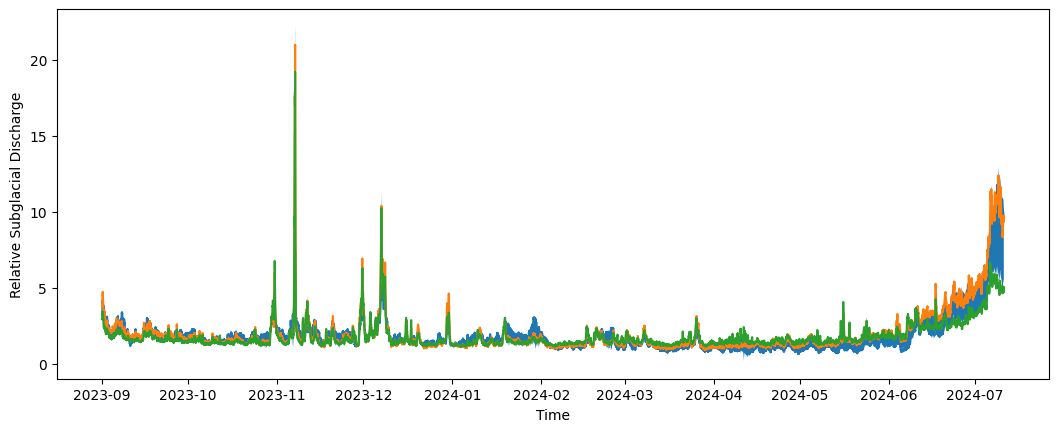

In [9]:
fig = plt.figure(figsize=(2*6.4,4.8))
for freqbound in freqbounds:
    plt.plot(df_ght.index, np.sqrt(df_ght[freqbound]))
    # plt.fill_between(df_ght.index, df_ght[freqbound], df_ght[freqbound])
plt.fill_between(df_ght.index, np.sqrt(df_ght['mean']-df_ght['std']), np.sqrt(df_ght['mean']+df_ght['std']))
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')

df_ght

## Week 8

In [ ]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

melt = np.vstack((PxxArr[1:100], PxxArr[-67:]))

In [16]:
weather = pd.read_csv("meteo_bay_2022-24.csv")
weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2023) & (weather["Month"] > 8)) | 
                  ((weather["Year"] == 2024) & (weather["Month"] < 7)) |
                  ((weather["Year"] == 2024) & (weather["Month"] == 7) & (weather["Day"] < 11))]
temps = weather.groupby(["Year", "Month", "Day"])["Temp [C]"].mean().to_numpy()
temps = np.hstack((temps[1:100], temps[-67:]))
warm = melt[temps >= np.median(temps)]
cool = melt[temps < np.median(temps)]

In [17]:
rows_warm = 10*np.log10(warm).T
rows_cool = 10*np.log10(cool).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_warm = np.ones(precision)
histograms_cool = np.ones(precision)

for row in rows_warm:
    histograms_warm = np.vstack((histograms_warm, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_warm = histograms_warm / d_amplitude / len(rows_warm)

for row in rows_cool:
    histograms_cool = np.vstack((histograms_cool, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_cool = histograms_cool / d_amplitude / len(rows_cool)

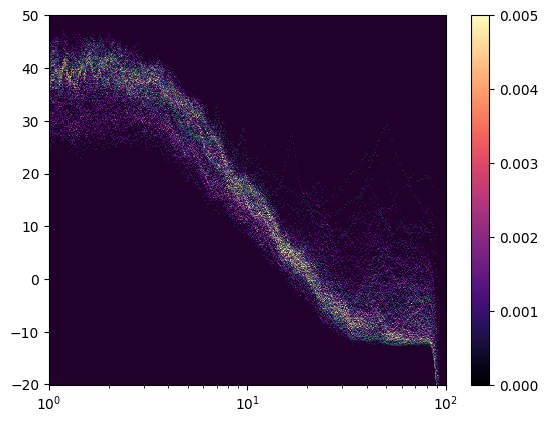

In [19]:
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_warm.T, vmin = 0, vmax = 0.005, cmap = "magma") 
plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_cool.T, vmin = 0, vmax = 0.005, cmap = "viridis", alpha = 0.5)
plt.xscale('log')
plt.xlim(1, 100)
plt.colorbar(im)

2024-07-01T00:00:00.000000Z 2024-07-01T01:00:00.000000Z
2024-07-01T01:00:00.000000Z 2024-07-01T02:00:00.000000Z
2024-07-01T02:00:00.000000Z 2024-07-01T03:00:00.000000Z
2024-07-01T03:00:00.000000Z 2024-07-01T04:00:00.000000Z
2024-07-01T04:00:00.000000Z 2024-07-01T05:00:00.000000Z
2024-07-01T05:00:00.000000Z 2024-07-01T06:00:00.000000Z
2024-07-01T06:00:00.000000Z 2024-07-01T07:00:00.000000Z
2024-07-01T07:00:00.000000Z 2024-07-01T08:00:00.000000Z
2024-07-01T08:00:00.000000Z 2024-07-01T09:00:00.000000Z
2024-07-01T09:00:00.000000Z 2024-07-01T10:00:00.000000Z
2024-07-01T10:00:00.000000Z 2024-07-01T11:00:00.000000Z
2024-07-01T11:00:00.000000Z 2024-07-01T12:00:00.000000Z
2024-07-01T12:00:00.000000Z 2024-07-01T13:00:00.000000Z
2024-07-01T13:00:00.000000Z 2024-07-01T14:00:00.000000Z
2024-07-01T14:00:00.000000Z 2024-07-01T15:00:00.000000Z
2024-07-01T15:00:00.000000Z 2024-07-01T16:00:00.000000Z
2024-07-01T16:00:00.000000Z 2024-07-01T17:00:00.000000Z
2024-07-01T17:00:00.000000Z 2024-07-01T18:00:00.

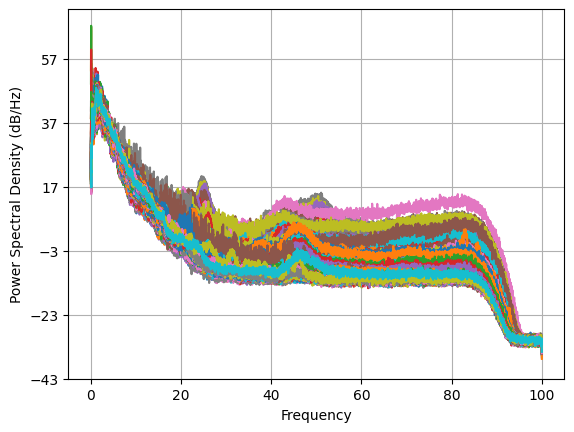

In [ ]:
# Read data
client = Client('QJT_data')

t_start = UTCDateTime('2024-07-01')
t_end = t_start + 3600
# only read 1 station and 1 channel for now

PxxArr = np.ones(6001)
freqsArr = np.ones(6001)

while t_start < UTCDateTime('2024-07-11'):
    print(t_start, t_end)
    stream = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
    stream.merge()
    tr = stream.select(component='Z')[0]
    data = tr.data
    fs = tr.stats.sampling_rate #sampling rate
    NFFT = int(fs*60)
    Pxx, freqs = plt.psd(x=data, NFFT=NFFT, Fs=fs, detrend = 'linear') # run this again w/ detrend, fixes linear drift
    t_start = t_end
    t_end = t_end + 3600
    PxxArr = np.vstack((PxxArr, Pxx))
    freqsArr = np.vstack((freqsArr, freqs))

In [22]:
quiet = PxxArr[:(24 * 6) + 1]
loud = PxxArr[(24 * 6) + 1:]

rows_quiet = 10*np.log10(quiet).T
rows_loud = 10*np.log10(loud).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_quiet = np.ones(precision)
histograms_loud = np.ones(precision)

for row in rows_quiet:
    histograms_quiet = np.vstack((histograms_quiet, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_quiet = histograms_quiet / d_amplitude / len(rows_quiet)

for row in rows_loud:
    histograms_loud = np.vstack((histograms_loud, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_loud = histograms_loud / d_amplitude / len(rows_loud)

In [3]:
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_quiet.T, vmin = 0, vmax = 0.005, cmap = "viridis") 
plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_loud.T, vmin = 0, vmax = 0.005, cmap = "magma", alpha = 0.5)
plt.xscale('log')
plt.xlim(1, 100)
plt.colorbar(im)

NameError: name 'amplitudes' is not defined

## Week 7

In [32]:
weather = pd.read_csv("meteo_bay_2022-24.csv")
weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2023) & (weather["Month"] > 8)) | 
                  ((weather["Year"] == 2024) & (weather["Month"] < 7)) |
                  ((weather["Year"] == 2024) & (weather["Month"] == 7) & (weather["Day"] < 11))]
temps = weather.groupby(["Year", "Month", "Day"])["Temp [C]"].mean().to_numpy()
temps = temps[100:-67]

data = np.load('psd.npz')
freqsArr = data['freqsArr'][1:]
PxxArr = data['PxxArr'][1:]
freqsArr = freqsArr[100:-67]
PxxArr = PxxArr[100:-67]

warm = PxxArr[temps >= 0]
cool = PxxArr[temps < 0]

In [36]:
rows_warm = 10*np.log10(warm).T
rows_cool = 10*np.log10(cool).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_warm = np.ones(precision)
histograms_cool = np.ones(precision)

for row in rows_warm:
    histograms_warm = np.vstack((histograms_warm, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_warm = histograms_warm / d_amplitude / len(rows_warm)

for row in rows_cool:
    histograms_cool = np.vstack((histograms_cool, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_cool = histograms_cool / d_amplitude / len(rows_cool)

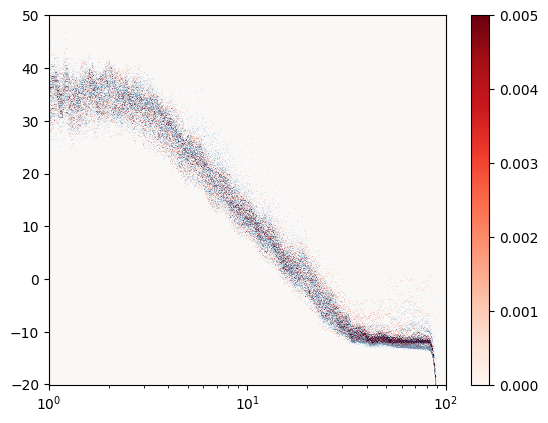

In [42]:
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_warm.T, vmin = 0, vmax = 0.005, cmap = "Reds") 
plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_cool.T, vmin = 0, vmax = 0.005, cmap = "Blues", alpha = 0.5)
plt.xscale('log')
plt.xlim(1, 100)
plt.colorbar(im)

In [18]:

len(temps[temps >= 0])

46

In [ ]:
# Example for July 2024
t_start = datetime.datetime(2024,7,1)
t_end = datetime.datetime(2024,7,30)

# List of seismometer stations to use
stations = ['QJT01', 'QJT02', 'QJT03']

# Times when valid seismometer data starts
start_dict = {'QJT01': datetime.datetime(2023,8,11,19),
             'QJT02': datetime.datetime(2023,8,14,19),
             'QJT03': datetime.datetime(2023,8,2,16)}

# Only looking at the vertical component
component = 'Z'

# Frequency range in which subglacial tremor is suspected (may be 3-30Hz)
freqmin = 3
freqmax = 7

# Path to the data !!! needs to be adjusted !!!
client = Client('QJT_data')

In [ ]:
# Extract glacier hydraulic tremor signal from seismometer data with strong calving events.

GHT_dict = {}

for sta in stations:
    print('\n'+sta)
    t_list = []  # timestamps
    min_list = []  # integrated power in frequency band used for minimum search
    Pxx_min_list = []  # entire PSD at minimum

    # Set start time to the very beginning
    t_start_loop = t_start
    while t_start_loop<t_end:
        print(t_start_loop, end='\r')
        
        # Read data
        st = client.get_waveforms('XH', sta, '', '*'+component,
                                     UTCDateTime(t_start_loop), 
                                     UTCDateTime(t_start_loop+datetime.timedelta(days=1)))
        st.merge(fill_value=0)  # fills data gaps and makes handling easier
        if len(st)>0 and st[0].stats.npts>1:  # only do the analysis if data is present
            
            # Remove data when people were present at station
            if st[0].stats.starttime.date == start_dict[sta].date():
                st.trim(UTCDateTime(start_dict[sta]), st[0].stats.endtime)
              
            # Calculate spectrogram
            Fs = st[0].stats.sampling_rate
            NFFT = 5*Fs  # 5s bins for FFT
            Pxx, freqs, bins, _ = plt.specgram(st[0].data, NFFT=int(NFFT), Fs=Fs, noverlap=0)
            plt.close()
    
            # Select relevant data for minimum power detection
            idx_low = (np.abs(freqs - freqmin)).argmin()
            idx_high = (np.abs(freqs - freqmax)).argmin()
            Pxx_cut = Pxx[idx_low:idx_high]
            freqs_cut = freqs[idx_low:idx_high]
        
            # Integrate over selected frequency band
            Pxx_int = np.sum(Pxx_cut, axis=0)
        
            # Define chunk size in bins
            chunk_size = int(10*60 / (NFFT/Fs))  # 10min
            
            # Calculate how much padding is needed (if len(bins)%chunk_size!=0)
            padding_length = chunk_size - (len(Pxx_int) % chunk_size)
            if padding_length != chunk_size:  # Only pad if necessary
                Pxx_int = np.pad(Pxx_int, (0, padding_length), constant_values=np.nan)
                bins = np.pad(bins, (0, padding_length), constant_values=np.nan)
                Pxx = np.pad(Pxx, pad_width=((0, 0), (0, padding_length)), constant_values=np.nan)
    
            # Reshape into chunks
            reshaped_data = Pxx_int.reshape(-1, chunk_size)
            reshaped_bins = bins.reshape(-1, chunk_size)
            Pxx = Pxx.reshape(Pxx.shape[0], int(Pxx.shape[1]/chunk_size), -1).transpose(1,0,2)
            
            # Calculate the minimum of each chunk
            min_values = np.nanmin(reshaped_data, axis=1)
            min_idx = np.argmin(reshaped_data, axis=1)
            
            # Get PSD with minimum power
            Pxx_select = Pxx[np.arange(Pxx.shape[0]),:,min_idx].T
            
            # Fake timestamp of chunk (center of bin)
            t_stamps = [(st[0].stats.starttime+t).datetime for t in np.nanmean(reshaped_bins, axis=1)]

            # Append to lists
            min_list.append(min_values)
            t_list.append(t_stamps)
            Pxx_min_list.append(Pxx_select)

        # Continue in while loop
        t_start_loop+=datetime.timedelta(days=1)

    # Convert list of arrays to array
    t_all = np.concatenate(t_list)
    min_all = np.concatenate(min_list)
    Pxx_all = np.concatenate(Pxx_min_list, axis=1)

    # Save results for each station into dictionary
    GHT_dict[sta] = {'t': t_all,
                     'GHT': min_all,
                     'PSD': Pxx_all}


QJT01


In [5]:
# Calculate mean GHT between stations
df_list = []

# Put GHT data into DataFrames
for sta in GHT_dict.keys():
    t = GHT_dict[sta]['t'].copy()
    GHT = GHT_dict[sta]['GHT'].copy()
    df = pd.DataFrame(data=GHT, index=t, columns=[sta])
    df = df.iloc[:-2] # remove some data when humans were reading out data at the station
    df_list.append(df)

# Merge the three DataFrames into a single one
df_ght = pd.concat(df_list, axis='columns')

# Normalization
df_ght = df_ght.divide(df_ght.median(skipna=True))

# Rolling averaging for each station
df_ght = df_ght.rolling('6h', center=True).median()

# Mean between stations
df_ght['mean'] = df_ght.mean(axis='columns')

# Setting GHT relative to minimum power
df_ght = df_ght / np.nanmin(df_ght['mean'])

# Standard Deviation
df_ght['std'] = df_ght[stations].std(axis='columns')

Text(0.5, 0, 'Time')

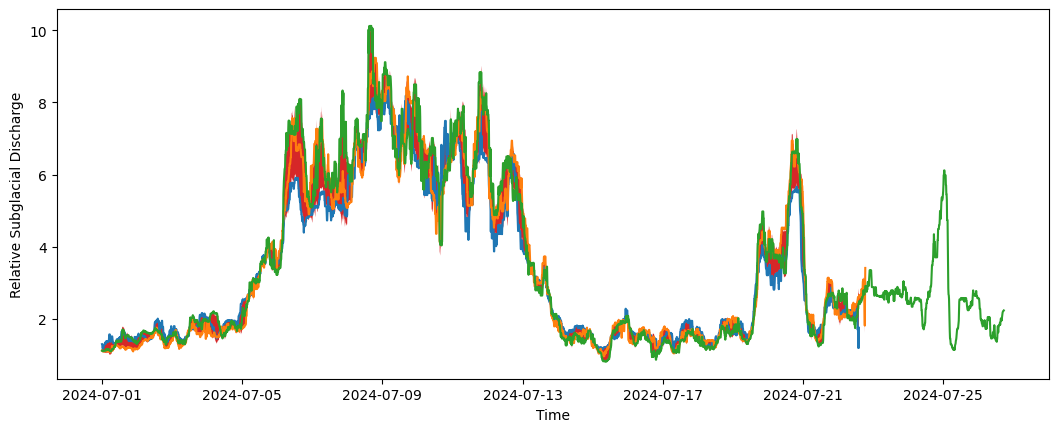

In [6]:
fig = plt.figure(figsize=(2*6.4,4.8))
for sta in stations:
    plt.plot(df_ght.index, df_ght[sta])
    plt.fill_between(df_ght.index, df_ght[sta], df_ght[sta])
plt.fill_between(df_ght.index, df_ght['mean']-df_ght['std'], df_ght['mean']+df_ght['std'])
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')

In [27]:
df_ght.index

DatetimeIndex(['2024-07-01 00:05:00', '2024-07-01 00:15:00',
               '2024-07-01 00:25:00', '2024-07-01 00:35:00',
               '2024-07-01 00:45:00', '2024-07-01 00:55:00',
               '2024-07-01 01:05:00', '2024-07-01 01:15:00',
               '2024-07-01 01:25:00', '2024-07-01 01:35:00',
               ...
               '2024-07-26 15:55:00', '2024-07-26 16:05:00',
               '2024-07-26 16:15:00', '2024-07-26 16:25:00',
               '2024-07-26 16:35:00', '2024-07-26 16:45:00',
               '2024-07-26 16:55:00', '2024-07-26 17:05:00',
               '2024-07-26 17:15:00', '2024-07-26 17:25:00'],
              dtype='datetime64[ns]', length=3705, freq='10min')

Text(0.5, 0, 'Time')

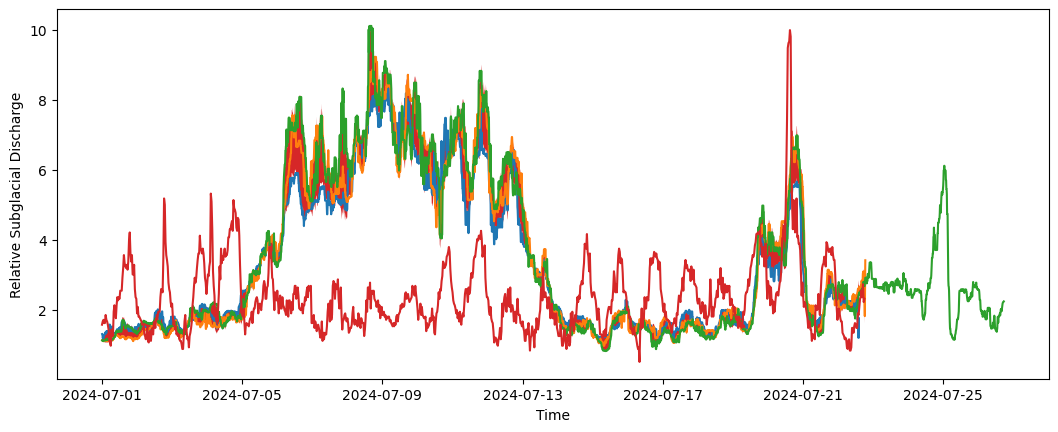

In [89]:
weather = pd.read_csv("meteo_bay_2022-24.csv")
weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2024) & (weather["Month"] == 7))]
temps = weather[["Time", "Temp [C]"]]
temps.loc[:,"Temp [C]"] = 10 * temps["Temp [C]"] / max(temps["Temp [C]"])
temps.loc[:,"Time"] = temps.loc[:,"Time"].apply(np.datetime64)

fig = plt.figure(figsize=(2*6.4,4.8))
for sta in stations:
    plt.plot(df_ght.index, df_ght[sta])
    plt.fill_between(df_ght.index, df_ght[sta], df_ght[sta])
plt.fill_between(df_ght.index, df_ght['mean']-df_ght['std'], df_ght['mean']+df_ght['std'])
plt.plot(temps["Time"], temps["Temp [C]"])
plt.ylabel('Relative Subglacial Discharge')
plt.xlabel('Time')


## Week 6

In [30]:
weather = pd.read_csv("meteo_bay_2022-24.csv")
weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2023) & (weather["Month"] > 8)) | 
                  ((weather["Year"] == 2024) & (weather["Month"] < 7)) |
                  ((weather["Year"] == 2024) & (weather["Month"] == 7) & (weather["Day"] < 11))]
temps = weather.groupby(["Year", "Month", "Day"])["Temp [C]"].mean().to_numpy()


array([ 5.72415381,  4.97582316,  5.06332029,  8.52636426,  5.40409855,
        5.34653465,  4.40709187,  4.58669123,  4.85609026,  5.484688  ,
        6.6682017 ,  4.32419986,  4.20907207,  5.02878195,  5.44554455,
        5.37877044,  5.61363113,  5.47317522,  6.81556528, 10.        ,
        6.04881418,  3.85335831])

In [ ]:
data = np.load('psd.npz')
freqsArr = data['freqsArr'][1:]
PxxArr = data['PxxArr'][1:]
warm = PxxArr[temps >= 5]
cool = PxxArr[temps < -5]

In [ ]:
rows_warm = 10*np.log10(warm).T
rows_cool = 10*np.log10(cool).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_warm = np.ones(precision)
histograms_cool = np.ones(precision)

for row in rows_warm:
    histograms_warm = np.vstack((histograms_warm, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_warm = histograms_warm / d_amplitude

for row in rows_cool:
    histograms_cool = np.vstack((histograms_cool, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_cool = histograms_cool / d_amplitude

In [ ]:
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_warm.T, vmin = 0, vmax = 20, cmap = "magma") 
plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_cool.T, vmin = 0, vmax = 20, cmap = "viridis", alpha = 0.5)
plt.xscale('log')
plt.xlim(1, 100)
plt.colorbar(im)

## Week 5

In [ ]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

melt = np.vstack((PxxArr[1:100], PxxArr[-67:]))
winter = PxxArr[100:-67]



In [ ]:
rows_melt = 10*np.log10(melt).T
rows_winter = 10*np.log10(winter).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_melt = np.ones(precision)
histograms_winter = np.ones(precision)

for row in rows_melt:
    histograms_melt = np.vstack((histograms_melt, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_melt = histograms_melt / d_amplitude

for row in rows_winter:
    histograms_winter = np.vstack((histograms_winter, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_winter = histograms_winter / d_amplitude


In [ ]:
# sns.heatmap(np.flip(histograms.T, 0))
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_melt.T, vmin = 0, vmax = 60, cmap = "magma") 
# plt.colorbar(im)
plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_winter.T, vmin = 0, vmax = 60, cmap = "viridis", alpha = 0.5)
plt.xscale('log')
plt.xlim(1, 100)
# plt.yscale('log')
plt.colorbar(im)

# print(np.shape(histograms.T))

In [ ]:
weather = pd.read_csv("meteo_bay_2022-24.csv")

weather["Year"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[0]))
weather["Month"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[1]))
weather["Day"] = weather["Time"].apply(lambda x: int(x[:10].split("-")[2]))
weather = weather[((weather["Year"] == 2023) & (weather["Month"] > 8)) | ((weather["Year"] == 2024) & (weather["Month"] < 7))]
temps = weather.groupby(["Year", "Month", "Day"])["Temp [C]"].mean()
sns.histplot(temps)
plt.axvline(temps.mean(), color="red", linestyle="--", label="Mean")
plt.axvline(temps.median(), color="blue", linestyle="--", label="Median")

In [ ]:
sns.lineplot(temps.to_numpy())
plt.axhline(temps.mean(), color="red", linestyle="--", label="Mean")
plt.axhline(temps.median(), color="blue", linestyle="--", label="Median")

In [ ]:
temps

## Week 4

In [ ]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

melt = np.vstack((PxxArr[1:100], PxxArr[-67:]))
winter = PxxArr[100:-67]

In [ ]:
for i in range(0, np.shape(melt)[0]):
    sns.lineplot(x=freqsArr[1], y=10*np.log10(melt[i]))

In [ ]:
rows_melt = 10*np.log10(melt).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_melt = np.ones(precision)

for row in rows_melt:
    histograms_melt = np.vstack((histograms_melt, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_melt = histograms_melt / d_amplitude


# sns.heatmap(np.flip(histograms.T, 0))
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_melt.T, vmin = 0, vmax = 60) 
plt.xscale('log')
plt.xlim(1, 100)
# plt.yscale('log')
plt.colorbar(im)

# print(np.shape(histograms.T))

In [ ]:
for i in range(0, np.shape(winter)[0]):
    sns.lineplot(x=freqsArr[1], y=10*np.log10(winter[i]))

In [ ]:
rows_winter = 10*np.log10(winter).T

precision = 500
amplitudes = np.linspace(-20, 50, precision) 
d_amplitude = amplitudes[1]-amplitudes[0]
histograms_winter = np.ones(precision)

for row in rows_winter:
    histograms_winter = np.vstack((histograms_winter, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms_winter = histograms_winter / d_amplitude


# sns.heatmap(np.flip(histograms.T, 0))
im = plt.pcolormesh(np.linspace(0, 100, 6002), amplitudes, histograms_winter.T, vmin = 0, vmax = 60)  
plt.xscale('log')
plt.xlim(1, 100)
# plt.yscale('log')
plt.colorbar(im)

# print(np.shape(histograms.T))

In [ ]:
# Read data
client = Client('QJT_data')

t_start = UTCDateTime('2024-01-01')
t_end = t_start + 10
# only read 1 station and 1 channel for now

PxxArr = np.ones(10001)
freqsArr = np.ones(10001)

while t_start < UTCDateTime('2024-01-01') + 3600:
    print(t_start, t_end)
    stream = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
    stream.merge()
    tr = stream.select(component='Z')[0]
    data = tr.data
    fs = tr.stats.sampling_rate #sampling rate
    NFFT = int(fs*10)
    Pxx, freqs = plt.psd(x=data, NFFT=NFFT, Fs=fs, detrend = 'linear', pad_to = 10 * NFFT) # run this again w/ detrend, fixes linear drift
    t_start = t_end
    t_end = t_end + 10
    PxxArr = np.vstack((PxxArr, Pxx))
    freqsArr = np.vstack((freqsArr, freqs))

# problematic days in 2023: 08/01, 08/02, 08/30
# and in 2024: 07/11
# last day 2024-07-27


In [ ]:
rows = 10*np.log10(PxxArr[1:]).T

precision = 100
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms = np.ones(precision)

for row in rows:
    histograms = np.vstack((histograms, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms = histograms[1:] / d_amplitude


# sns.heatmap(np.flip(histograms.T, 0))
im = plt.pcolormesh(np.linspace(0, 100, 10001), amplitudes, histograms.T, vmin = 0, vmax = 40)
plt.xscale('log')
plt.xlim(0.1, 100)
# plt.yscale('log')
plt.colorbar(im)

print(np.shape(histograms.T))

In [ ]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

In [ ]:
ind = False
low = -1
high = -1

for idx, val in enumerate(freqsArr[1]):
    if not ind and val > 3:
        ind = True
        low = idx
    elif val > 7:
        high = idx - 1
        break


# time_ser = np.sum(np.delete(np.delete(PxxArr, np.s_[high + 1:], 1), np.s_[:low], 1), 1)[1:]
time_ser = np.sum(PxxArr[:,low:high+1], 1)[1:]

sns.lineplot(time_ser)

## Week 3

In [1]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

NameError: name 'np' is not defined

In [ ]:
for i in range(0, 315):
    sns.lineplot(x=freqsArr[i], y=10*np.log10(PxxArr[i]))

In [ ]:
rows = 10*np.log10(PxxArr[1:]).T

precision = 500
amplitudes = np.linspace(-20, 50, precision)
d_amplitude = amplitudes[1]-amplitudes[0]
histograms = np.ones(precision)

for row in rows:
    histograms = np.vstack((histograms, scipy.ndimage.histogram(row, -20, 50, precision)))
histograms = histograms[1:] / d_amplitude


# sns.heatmap(np.flip(histograms.T, 0))
im = plt.pcolormesh(np.linspace(0, 100, 6001), amplitudes, histograms.T, vmin = 0, vmax = 60)
plt.xscale('log')
plt.xlim(1, 100)
# plt.yscale('log')
plt.colorbar(im)

print(np.shape(histograms.T))

## Week 2

2023-09-01T00:00:00.000000Z 2023-09-02T00:00:00.000000Z
2023-09-02T00:00:00.000000Z 2023-09-03T00:00:00.000000Z
2023-09-03T00:00:00.000000Z 2023-09-04T00:00:00.000000Z
2023-09-04T00:00:00.000000Z 2023-09-05T00:00:00.000000Z
2023-09-05T00:00:00.000000Z 2023-09-06T00:00:00.000000Z
2023-09-06T00:00:00.000000Z 2023-09-07T00:00:00.000000Z


KeyboardInterrupt: 

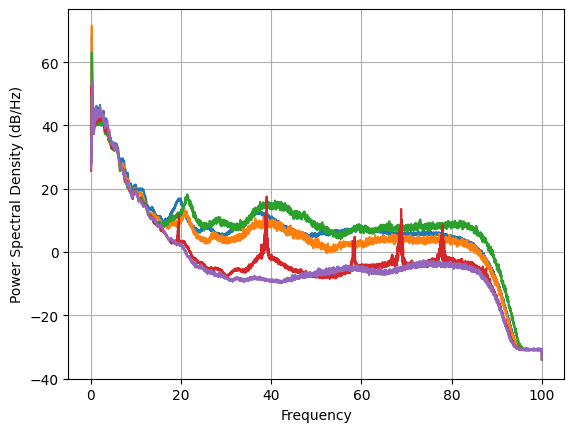

In [3]:
# Read data
client = Client('QJT_data')

t_start = UTCDateTime('2023-09-01')
t_end = t_start + 24*3600
# only read 1 station and 1 channel for now

PxxArr = np.ones(6001)
freqsArr = np.ones(6001)

while t_start < UTCDateTime('2024-07-11'):
    print(t_start, t_end)
    stream = client.get_waveforms('XH', 'QJT03', '', 'HHZ', t_start, t_end)
    stream.merge()
    tr = stream.select(component='Z')[0]
    data = tr.data
    fs = tr.stats.sampling_rate #sampling rate
    NFFT = int(fs*60)
    Pxx, freqs = plt.psd(x=data, NFFT=NFFT, Fs=fs, detrend = 'linear') # run this again w/ detrend, fixes linear drift
    t_start = t_end
    t_end = t_end + 24*3600
    PxxArr = np.vstack((PxxArr, Pxx))
    freqsArr = np.vstack((freqsArr, freqs))

# problematic days in 2023: 08/01, 08/02, 08/30
# and in 2024: 07/11
# last day 2024-07-27


In [ ]:
np.savez_compressed('psd.npz', freqsArr = freqsArr, PxxArr = PxxArr)

In [4]:
data = np.load('psd.npz')
freqsArr = data['freqsArr']
PxxArr = data['PxxArr']

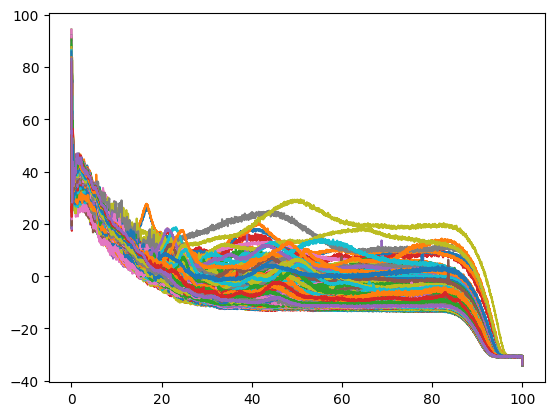

In [5]:
for i in range(0, 315):
    sns.lineplot(x=freqsArr[i], y=10*np.log10(PxxArr[i]))

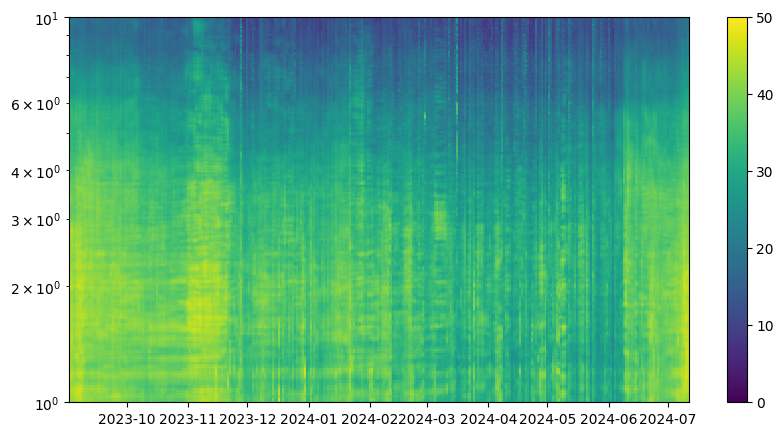

In [6]:
y = freqsArr[1]
start = UTCDateTime('2023-09-01').datetime
dt = datetime.timedelta(days = 1)
x = [start + n*dt for n in range(PxxArr.shape[0])] 
fig = plt.figure(figsize = (10, 5))
im = plt.pcolormesh(x[1:], y, 10*np.log10(PxxArr[1:]).T, vmin = 0, vmax = 50)
plt.colorbar(im)
plt.ylim(1,10)
plt.yscale('log')

## Week 1

In [ ]:
# Read data
client = Client('QJT_data')

t_start = UTCDateTime('2023-08-15')
t_end = UTCDateTime('2023-08-16')
# only read 1 station and 1 channel for now

sites = ['QJT01', 'QJT02', 'QJT03']
channels = ['HHE', 'HHN', 'HHZ']
streamlists = []
for site in sites:
    temp = []
    for channel in channels:
        temp.append(client.get_waveforms('XH', site, '', channel, t_start, t_end))
    streamlists.append(temp)

for streamlist in streamlists:
    for stream in streamlist:
        stream.merge()

In [ ]:
# Select vertical component as a trace and calculate power spectrum 
components = ['E', 'N', 'Z']
spectrograms = []

for streamlist in streamlists:
    for idx, stream in enumerate(streamlist):
        tr = stream.select(component = components[idx])[0]
        data = tr.data
        fs = tr.stats.sampling_rate #sampling rate
        NFFT = int(fs*60)
        Pxx, freqs, bins, _ = plt.specgram(data, NFFT=NFFT, Fs=fs)
        spectrograms.append([Pxx, freqs, bins])
        plt.close()
        


In [ ]:
for spectrogram in spectrograms:
    Pxx = spectrogram[0]
    freqs = spectrogram[1]
    lower_bound = -1
    upper_bound = -1
    lower_bound_found = False
    for idx, val in enumerate(freqs):
        if (lower_bound_found == False) and val > 1:
            lower_bound = idx
            lower_bound_found = True
        if val > 20:
            upper_bound = idx
            break

    lower_bound, upper_bound

    freqs = freqs[lower_bound:upper_bound]
    Pxx = Pxx[lower_bound:upper_bound]

In [ ]:
fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize=(6.4*2*3,4.8*3))

for idx, spectrogram in enumerate(spectrograms):
        Pxx = spectrogram[0]
        freqs = spectrogram[1]
        bins = spectrogram[2]
        
        dt_bins = bins[1]-bins[0]
        t_bins = [tr.stats.starttime.datetime+datetime.timedelta(seconds=t-dt_bins) for t in bins]

        row = idx // 3
        col = idx % 3

        im = axs[row, col].imshow(10*np.log10(Pxx), aspect='auto', origin='lower',
                extent=[t_bins[0], t_bins[-1], freqs[0], freqs[-1]],
                        vmin=0,vmax=75)
        axs[row, col].set_ylim(1,20)
        axs[row, col].set_yscale('log')
        axs[row, col].set_ylabel('Frequency [Hz]')
        axs[row, col].set_xlabel('Time')
        axs[row, col].set_title('Spectrogram of ' + channels[col] + ' at ' + sites[row])
        cbar = plt.colorbar(im, label='PSD [dB/Hz]')